In [39]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_parquet("data/sampled_user_month_traj.parquet")

In [60]:
# rating 기준으로 활성 파티산 유저 추출
political_users = df[df['demAlignedLessRepAlignedRatings'] != 0].copy()

rep_raters = political_users[political_users['demAlignedLessRepAlignedRatings'] < 0]
dem_raters = political_users[political_users['demAlignedLessRepAlignedRatings'] > 0]
rep_writers = political_users[political_users['demAlignedLessRepAlignedNotes'] < 0]
dem_writers = political_users[political_users['demAlignedLessRepAlignedNotes'] > 0]

Partisan alignment was determined based on each user's demAlignedLessRepAlignedRatings score, which is the total number of Dem-aligned ratings minus Rep-aligned ratings. This score does not represent each user's actual political beliefs, but rather how their behavior on the platform skews in a given month. A user with a negative score gave more Rep-aligned ratings than Dem-aligned ratings that month, and is classified as Rep-aligned for that period.

In [ ]:
# users that have both writing and rating data
both = df[(df['demAlignedLessRepAlignedNotes'] != 0) & 
          (df['demAlignedLessRepAlignedRatings'] != 0)].copy()

corr = both['demAlignedLessRepAlignedNotes'].corr(both['demAlignedLessRepAlignedRatings'])
print(f"writing-rating correlation: {corr:.3f}")

writing-rating correlation: 0.122


In [64]:
# rep writer들의 rating 행동
print("Rep writers's rating average:")
print(rep_writers[['antiDemRatings', 'proRepRatings', 'antiRepRatings', 'proDemRatings']].mean())

print("Dem writers's rating average:")
print(dem_writers[['antiDemRatings', 'proRepRatings', 'antiRepRatings', 'proDemRatings']].mean())

Rep writers's rating average:
antiDemRatings    12.722925
proRepRatings     21.620253
antiRepRatings     8.668073
proDemRatings      5.739803
dtype: float64
Dem writers's rating average:
antiDemRatings     7.391989
proRepRatings      8.349070
antiRepRatings    17.014306
proDemRatings     12.340486
dtype: float64


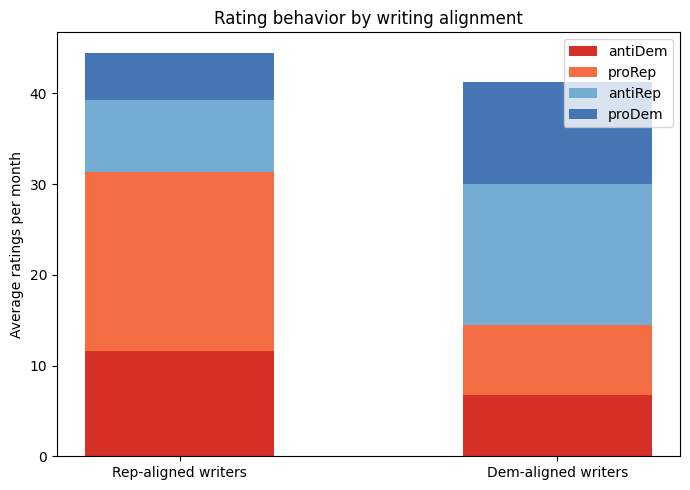

In [70]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Rep-aligned writers', 'Dem-aligned writers']
antiDem =  [11.639386, 6.787840]
proRep =   [19.680307, 7.697283]
antiRep =  [7.943734,  15.571798]
proDem =   [5.250639,  11.223803]

x = np.arange(len(categories))
width = 0.5

fig, ax = plt.subplots(figsize=(7, 5))
p1 = ax.bar(x, antiDem, width, label='antiDem',  color='#d73027')
p2 = ax.bar(x, proRep,  width, label='proRep',   color='#f46d43', bottom=antiDem)
p3 = ax.bar(x, antiRep, width, label='antiRep',  color='#74add1',
            bottom=[antiDem[i] + proRep[i] for i in range(2)])
p4 = ax.bar(x, proDem,  width, label='proDem',   color='#4575b4',
            bottom=[antiDem[i] + proRep[i] + antiRep[i] for i in range(2)])

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Average ratings per month')
ax.set_title('Rating behavior by writing alignment')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

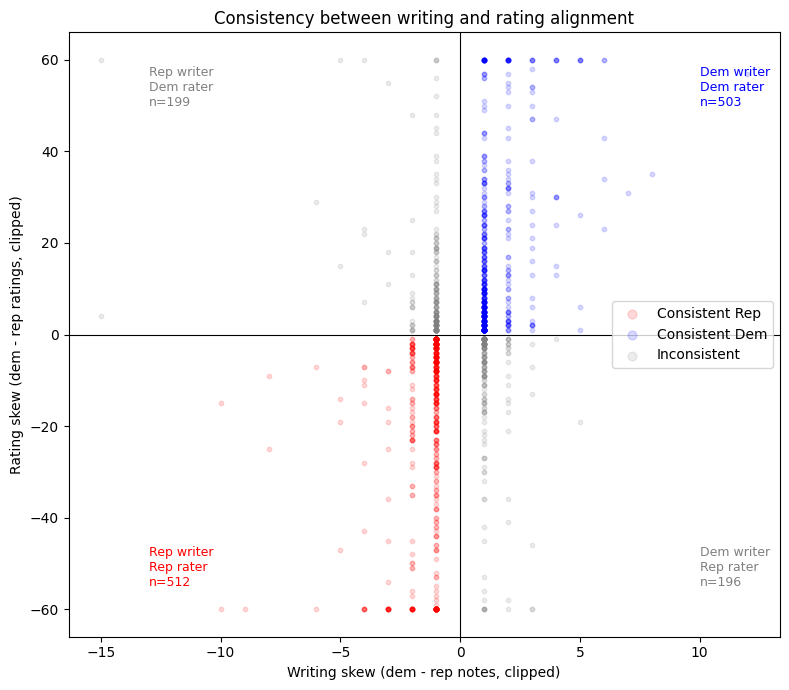

color
red     512
blue    503
gray    395
Name: count, dtype: int64
Consistent ratio: 72.0%


In [74]:
import matplotlib.pyplot as plt
import numpy as np

both = df[
    (df['demAlignedLessRepAlignedNotes'] != 0) &
    (df['demAlignedLessRepAlignedRatings'] != 0)
].copy()

both['notes_clipped'] = both['demAlignedLessRepAlignedNotes'].clip(-15, 15)
both['ratings_clipped'] = both['demAlignedLessRepAlignedRatings'].clip(-60, 60)

# 사분면별 색 지정
def get_color(row):
    n, r = row['notes_clipped'], row['ratings_clipped']
    if n < 0 and r < 0:
        return 'red'      # Rep writer, Rep rater = consistent Rep
    elif n > 0 and r > 0:
        return 'blue'     # Dem writer, Dem rater = consistent Dem
    else:
        return 'gray'     # inconsistent

both['color'] = both.apply(get_color, axis=1)

fig, ax = plt.subplots(figsize=(8, 7))
for color, label in [('red', 'Consistent Rep'), ('blue', 'Consistent Dem'), ('gray', 'Inconsistent')]:
    mask = both['color'] == color
    ax.scatter(
        both.loc[mask, 'notes_clipped'],
        both.loc[mask, 'ratings_clipped'],
        c=color, alpha=0.15, s=10, label=label
    )

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

# 사분면별 n 계산
n_rep = (both['color'] == 'red').sum()
n_dem = (both['color'] == 'blue').sum()
n_inc_top_left = ((both['notes_clipped'] < 0) & (both['ratings_clipped'] > 0)).sum()
n_inc_bot_right = ((both['notes_clipped'] > 0) & (both['ratings_clipped'] < 0)).sum()

# 기존 코드에서 사분면 라벨 부분을 이걸로 교체
ax.text(-13, -55, f'Rep writer\nRep rater\nn={n_rep}', color='red', fontsize=9)
ax.text(10, 50, f'Dem writer\nDem rater\nn={n_dem}', color='blue', fontsize=9)
ax.text(-13, 50, f'Rep writer\nDem rater\nn={n_inc_top_left}', color='gray', fontsize=9)
ax.text(10, -55, f'Dem writer\nRep rater\nn={n_inc_bot_right}', color='gray', fontsize=9)

ax.set_xlabel('Writing skew (dem - rep notes, clipped)')
ax.set_ylabel('Rating skew (dem - rep ratings, clipped)')
ax.set_title('Consistency between writing and rating alignment')
ax.legend(loc='center right', markerscale=2)
plt.tight_layout()
plt.show()

# 사분면별 유저 수 확인
print(both['color'].value_counts())
print(f"Consistent ratio: {(both['color'] != 'gray').mean():.1%}")

The stacked bar chart shows the breakdown of rating behavior for Rep-aligned and Dem-aligned writers. Rep-aligned writers give more ratings overall, with proRep ratings making up the largest single portion of their total. This confirms that Rep-aligned users express their partisanship primarily through supporting their own side rather than attacking the other. Dem-aligned writers give fewer ratings in total, but their largest portion is antiRep, meaning they are more attack-oriented than support-oriented. The blue portions, proDem and antiRep, dominate the Dem-aligned bar, while the red portions, proRep and antiDem, dominate the Rep-aligned bar, showing that both groups rate in ways that match their writing direction. 

The quadrant plot supports the low correlation. Most users cluster near zero on the writing axis but show strong rating skew in both directions, meaning rating behavior is a stronger and more common signal of partisan alignment than writing behavior. Of the users who showed partisan behavior in either dimension, 72% were consistent across both, with Rep-consistent users (n=512) and Dem-consistent users (n=503) nearly equal in size. The remaining 28% were inconsistent, writing notes that leaned one way but rating in the opposite direction. This suggests that while most partisan users do behave consistently, a meaningful minority either rate more casually than they write, or deliberately rate in a more neutral way to maintain credibility in the system.

In [85]:
from sklearn.ensemble import RandomForestClassifier


features = [ "proDemRatings", "antiDemRatings", "proRepRatings", "antiRepRatings" ]

df["dem_share"] = (
    df["proDemRatings"] + df["antiRepRatings"]
) / (
    df["proDemRatings"] +
    df["antiRepRatings"] +
    df["proRepRatings"] +
    df["antiDemRatings"]
).replace(0, np.nan)

y = (df["dem_share"] > 0.5).astype(int)

X = df[features].fillna(0)
y = (df["dem_share"] > 0.5).astype(int)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

rf.fit(X, y)

import pandas as pd
pd.Series(rf.feature_importances_, index=features)

proDemRatings     0.233282
antiDemRatings    0.095702
proRepRatings     0.114345
antiRepRatings    0.556671
dtype: float64

Feature importance from a Random Forest model indicates that out-group negativity, particularly anti-Republican ratings, is the strongest predictor of Democratic alignment, while pro-Democratic behavior plays a secondary role. This indicates that partisan alignment is primarily expressed through differential engagement with opposing political groups rather than purely through support of in-group content.